In [7]:
import pandas as pd

airlines = pd.read_csv("../data/airlines.csv")
airlines.head()

,Airline,Flight,AirportFrom,AirportTo,DayOfWeek,Time,Length,Delay
0,CO,269,SFO,IAH,3,15,205,1
1,US,1558,PHX,CLT,3,15,222,1
2,AA,2400,LAX,DFW,3,20,165,1
3,AA,2466,SFO,DFW,3,20,195,1
4,AS,108,ANC,SEA,3,30,202,0


## Estructura general

Antes de meternos con las variables individuales, vale la pena ver qué tan grande es el dataset y qué tipo de dato trae cada columna.

In [8]:
airlines.shape

(539383, 8)

In [9]:
airlines.dtypes

Airline          str
Flight         int64
AirportFrom      str
AirportTo        str
DayOfWeek      int64
Time           int64
Length         int64
Delay          int64
dtype: object

## Valores faltantes

Revisamos si hay columnas con datos nulos, ya que eso condiciona el preprocesamiento que vamos a necesitar más adelante.

In [10]:
airlines.isnull().sum()

Airline        0
Flight         0
AirportFrom    0
AirportTo      0
DayOfWeek      0
Time           0
Length         0
Delay          0
dtype: int64

## Variable objetivo: `Delay`

`Delay` indica si el vuelo se retrasó (1) o no (0). Miramos qué tan balanceadas están las dos clases, porque eso afecta cómo vamos a evaluar los modelos más adelante.

In [11]:
airlines["Delay"].value_counts(normalize=True)

Delay
0    0.554558
1    0.445442
Name: proportion, dtype: float64

## Aerolíneas más frecuentes

Vemos qué aerolíneas concentran más vuelos en el dataset.

In [12]:
airlines["Airline"].value_counts().head(10)

Airline
WN    94097
DL    60940
OO    50254
AA    45656
MQ    36605
US    34500
XE    31126
EV    27983
UA    27619
CO    21118
Name: count, dtype: int64

## Retrasos por día de la semana

Ahora cruzamos `DayOfWeek` con `Delay` para ver si hay días con mayor proporción de vuelos retrasados.

In [13]:
airlines.groupby("DayOfWeek")["Delay"].mean().sort_index()

DayOfWeek
1    0.467644
2    0.447337
3    0.470818
4    0.451025
5    0.416608
6    0.400553
7    0.453541
Name: Delay, dtype: float64

## Aeropuertos de origen más frecuentes

También conviene ver desde qué aeropuertos salen más vuelos, para entender qué tan concentrados están los datos geográficamente.

In [14]:
airlines["AirportFrom"].value_counts().head(10)

AirportFrom
ATL    34449
ORD    24822
DFW    22154
DEN    19843
LAX    16657
IAH    15821
PHX    15557
DTW    13136
LAS    11918
SFO    11786
Name: count, dtype: int64

## Variables numéricas: hora y duración del vuelo

`Time` es la hora programada del vuelo (en minutos desde medianoche) y `Length` es la duración en minutos. Miramos su distribución general.

In [15]:
airlines[["Time", "Length"]].describe()

,Time,Length
count,539383.000000,539383.000000
mean,802.728963,132.202007
std,278.045911,70.117016
min,10.000000,0.000000
25%,565.000000,81.000000
50%,795.000000,115.000000
75%,1035.000000,162.000000
max,1439.000000,655.000000


## Duración del vuelo vs. retraso

Por último, comparamos la duración promedio de los vuelos retrasados contra los que no, para ver si hay alguna relación aparente entre ambas variables.

In [16]:
airlines.groupby("Delay")["Length"].mean()

Delay
0    129.657594
1    135.369697
Name: Length, dtype: float64

## Duplicados
Revisamos si hay filas exactamente iguales, lo cual puede indicar vuelos recurrentes (misma ruta, mismo horario, distintas semanas) o un problema de carga de datos.

In [17]:
airlines.duplicated().sum()

np.int64(216618)

## Outliers en variables numéricas
Buscamos valores fuera de rango razonable, como duraciones de vuelo de 0 minutos u horas fuera del rango esperado.

Time         Axes(0.125,0.11;0.352273x0.77)
Length    Axes(0.547727,0.11;0.352273x0.77)
dtype: object

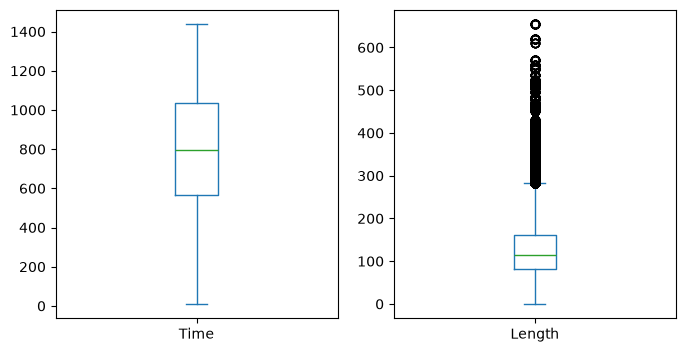

In [21]:
airlines[airlines["Length"] == 0].shape[0]

airlines[["Time", "Length"]].plot(kind="box", subplots=True, figsize=(8, 4))

## Correlación entre variables numéricas
Vemos qué tan relacionadas están las variables numéricas entre sí y con la variable objetivo.

In [22]:
airlines[["Flight", "DayOfWeek", "Time", "Length", "Delay"]].corr()

,Flight,DayOfWeek,Time,Length,Delay
Flight,1.000000,0.000416,-0.005750,-0.341481,-0.046175
DayOfWeek,0.000416,1.000000,0.001273,0.013397,-0.026199
Time,-0.005750,0.001273,1.000000,-0.020612,0.150454
Length,-0.341481,0.013397,-0.020612,1.000000,0.040489
Delay,-0.046175,-0.026199,0.150454,0.040489,1.000000


## Hora del vuelo vs. retraso
Comparamos la hora programada del vuelo entre los que se retrasaron y los que no, para ver si hay franjas horarias más propensas a retrasos.

array([<Axes: title={'center': '0'}>, <Axes: title={'center': '1'}>],
      dtype=object)

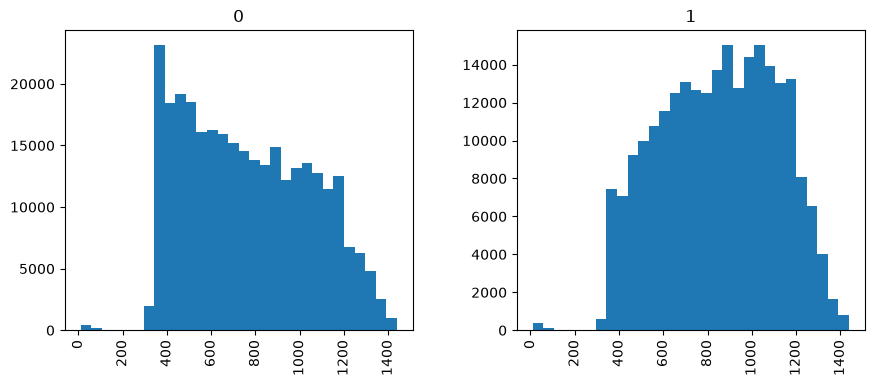

In [23]:
airlines.groupby("Delay")["Time"].mean()

airlines["Time"].hist(by=airlines["Delay"], bins=30, figsize=(10, 4))

## Tasa de retraso por aerolínea
En vez de solo ver qué aerolíneas tienen más vuelos, vemos cuáles tienen mayor proporción de retrasos.

In [24]:
airlines.groupby("Airline")["Delay"].mean().sort_values(ascending=False)

Airline
WN    0.697759
CO    0.566199
B6    0.467038
OO    0.452899
DL    0.450476
F9    0.449040
EV    0.402208
9E    0.397660
AA    0.388470
XE    0.378944
MQ    0.348095
AS    0.339290
US    0.335971
UA    0.323907
HA    0.320186
FL    0.301292
OH    0.277276
YV    0.242914
Name: Delay, dtype: float64

## Distribución de variables numéricas
Histogramas de `Time` y `Length` para ver su forma general.

array([[<Axes: title={'center': 'Time'}>,
        <Axes: title={'center': 'Length'}>]], dtype=object)

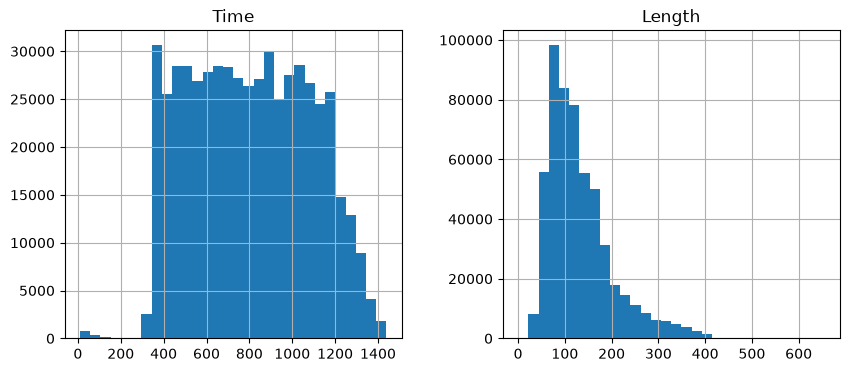

In [25]:
airlines[["Time", "Length"]].hist(bins=30, figsize=(10, 4))

## Conclusiones actualizadas

- El dataset tiene **539383 filas y 8 columnas**, no hay nulos en ninguna columna, en cuanto a completitud esta limpio.
- La variable objetivo `Delay` esta balanceada, **55.5% no se retraso y 44.5% si**, por lo que no es necesario aplicar tecnicas de balanceo de clases para el modelado.
- **Southwest (WN)** es la aerolinea con mas vuelos del dataset (aproximadamente 94k), y tambien es la que tiene mayor proporcion de retrasos, cerca del **70%** de sus vuelos. En contraste, YV tiene la menor proporcion de retrasos, alrededor del 24%. Esto indica que la aerolinea tiene una relacion mas marcada con el retraso que las demas variables analizadas.
- Los **viernes y sabados** presentan menor proporcion de retrasos (40-42%) comparado con el resto de la semana (45-47%), lo que sugiere que el dia de la semana puede aportar como variable.
- Los aeropuertos de origen con mas vuelos corresponden a los hubs mas grandes de Estados Unidos (ATL, ORD, DFW, DEN, LAX), lo cual es consistente con el volumen de trafico que manejan.
- Se encontraron **4 vuelos con `Length` igual a 0 minutos**, lo cual no es valido para la duracion de un vuelo y corresponde a un problema de calidad de datos. Al ser pocos registros, se pueden eliminar sin mayor impacto.
- La correlacion entre las variables numericas es en general debil. Se destaca `Flight` con `Length` (-0.34), donde vuelos con numero de flight mas alto tienden a tener menor duracion, y `Time` con `Delay` (0.15), una relacion positiva debil. Esto se confirma al comparar el promedio de `Time`: los vuelos retrasados salen en promedio **a las 2:09pm (849 minutos)**, mientras que los no retrasados salen **a la 1:45pm (765 minutos)** en promedio, lo que sugiere que los vuelos programados mas tarde en el dia tienen mayor probabilidad de retraso.
- La duracion del vuelo (`Length`) no muestra una relacion fuerte con el retraso: los vuelos retrasados duran en promedio 135 minutos y los no retrasados 130 minutos, una diferencia minima.
- Se encontraron **216618 filas duplicadas**, aproximadamente el 40% del dataset. El dataset no incluye una columna de fecha, solo `DayOfWeek`, por lo que estas filas podrian corresponder a vuelos recurrentes con el mismo numero de vuelo, ruta y horario en distintas semanas, y no necesariamente a un error de carga. Este punto requiere mayor investigacion y debe quedar documentado en el reporte.
- En resumen, las variables con mayor relacion aparente con `Delay` son `Airline` y `Time`, mientras que `Length` y `DayOfWeek` muestran una relacion mas debil por si solas.